# Composer Classification from MIDI

I cut pieces by Bach, Mozart, Chopin and Beethoven into 30 second snippets and train two models to guess who wrote each one: an LSTM and a 1D CNN.

## Imports and random seed
random seed so runs are reproducible. The four composers of interest are defined.

In [2]:
import hashlib, io, random, tempfile, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import tensorflow as tf
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (Attention, Bidirectional, Conv1D, Dense, Dropout,
                                     GlobalAveragePooling1D, GlobalMaxPooling1D, Input,
                                     LSTM, Masking, MaxPooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

SEED = 21
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)

composers = ["Bach", "Mozart", "Chopin", "Beethoven"]

## Kaggle Dataset Download
Authenticates with the Kaggle API, downloads the midi-classic-music zip. Stores the raw zip bytes in memory. Need Kaggle credentials in .kaggle/

In [3]:
#Authenticate
api = KaggleApi()
api.authenticate()

#Dataset Download into tmp directory/memory
with tempfile.TemporaryDirectory() as temp_folder:
    api.dataset_download_files("blanderbuss/midi-classic-music",
                               path=temp_folder, quiet=False, force=True)
    zip_bytes = list(Path(temp_folder).glob("*.zip"))[0].read_bytes()

Dataset URL: https://www.kaggle.com/datasets/blanderbuss/midi-classic-music


100%|██████████| 68.2M/68.2M [00:03<00:00, 23.2MB/s]

## Note Extraction From Midi File + Hashing

Opens the zip and parses every MIDI file for the composers. Extracts notes from MIDI file. Skips files that fail to load and stores a content hash for duplicate detection in later steps based upon notes.

In [4]:
#Create dictionary storage structure
midi_data = {}
for composer in composers:
    midi_data[composer] = {}

failed_files = 0
zip_file = zipfile.ZipFile(io.BytesIO(zip_bytes))

#Composer Parsing, Note Extraction, Hashing
for file_name in zip_file.namelist():
    parts = Path(file_name).parts
    if not file_name.lower().endswith((".mid", ".midi")):
        continue
    if len(parts) < 2 or parts[0] != "midiclassics":
        continue
    composer = parts[1]
    if composer not in composers:
        continue
    try:
        midi = pretty_midi.PrettyMIDI(io.BytesIO(zip_file.read(file_name)))
    except Exception:
        failed_files = failed_files + 1
        continue
    notes = []
    for instrument_number, instrument in enumerate(midi.instruments):
        for note in instrument.notes:
            notes.append({"pitch": int(note.pitch),
                          "start": float(note.start),
                          "end": float(note.end),
                          "velocity": int(note.velocity),
                          "duration": float(note.end - note.start),
                          "instrument": instrument_number})
    notes.sort(key=lambda note: note["start"])
    duration = float(midi.get_end_time())
    fingerprint = []
    for note in notes:
        fingerprint.append((note["pitch"] % 12, round(note["start"], 1), round(note["duration"], 1)))
    fingerprint.sort()
    midi_data[composer][Path(file_name).stem] = {
        "notes": notes,
        "duration": duration,
        "num_instruments": len(midi.instruments),
        "notes_per_second": len(notes) / duration if duration > 0 else 0,
        "content_hash": hashlib.md5(str(fingerprint).encode()).hexdigest(),
        "original_path": file_name,
    }

#File count Reporting
zip_file.close()
print("Files that could not be read:", failed_files)
print("\nTotal Files Parsed:")
for composer in composers:
    print("  ", composer, "-->", len(midi_data[composer]), "files")

C:\Users\Sadek\Documents\PythonEnvironments\20260727_BaseEnvSpyder\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Files that could not be read: 2

Total Files Parsed:
   Bach --> 1024 files
   Mozart --> 256 files
   Chopin --> 136 files
   Beethoven --> 212 files


## Histogram Plotting Functions
plot number of instruments, note duration, notes per second

In [5]:
def draw_histogram(plot, values, label, color, title, whole_numbers=False):
    bins = range(1, max(values) + 2) if whole_numbers else 25
    average = np.mean(values)
    plot.hist(values, bins=bins, color=color, edgecolor="black", alpha=0.8)
    plot.axvline(average, color="red", linestyle="--", label="Mean: " + str(round(average, 1)))
    plot.set_title(title, fontsize=11)
    plot.set_xlabel(label)
    plot.set_ylabel("Count")
    plot.legend(fontsize=8)

def plot_piece_histograms(data, title):
    metrics = ["num_instruments", "duration", "notes_per_second"]
    labels = ["Instruments", "Duration (s)", "Notes / Second"]
    colors = ["blue", "orange", "green"]
    figure, axes = plt.subplots(3, 4, figsize=(18, 12))
    figure.suptitle(title, fontsize=16)
    for column, composer in enumerate(composers):
        pieces = list(data[composer].values())
        for row in range(3):
            values = []
            for piece in pieces:
                values.append(piece[metrics[row]])
            draw_histogram(axes[row, column], values, labels[row], colors[row],
                           composer + " - " + labels[row],
                           whole_numbers=(metrics[row] == "num_instruments"))
    plt.tight_layout()
    plt.show()

## Plot Distributions of Composer vs MIDI info Before Deduplication & Filter

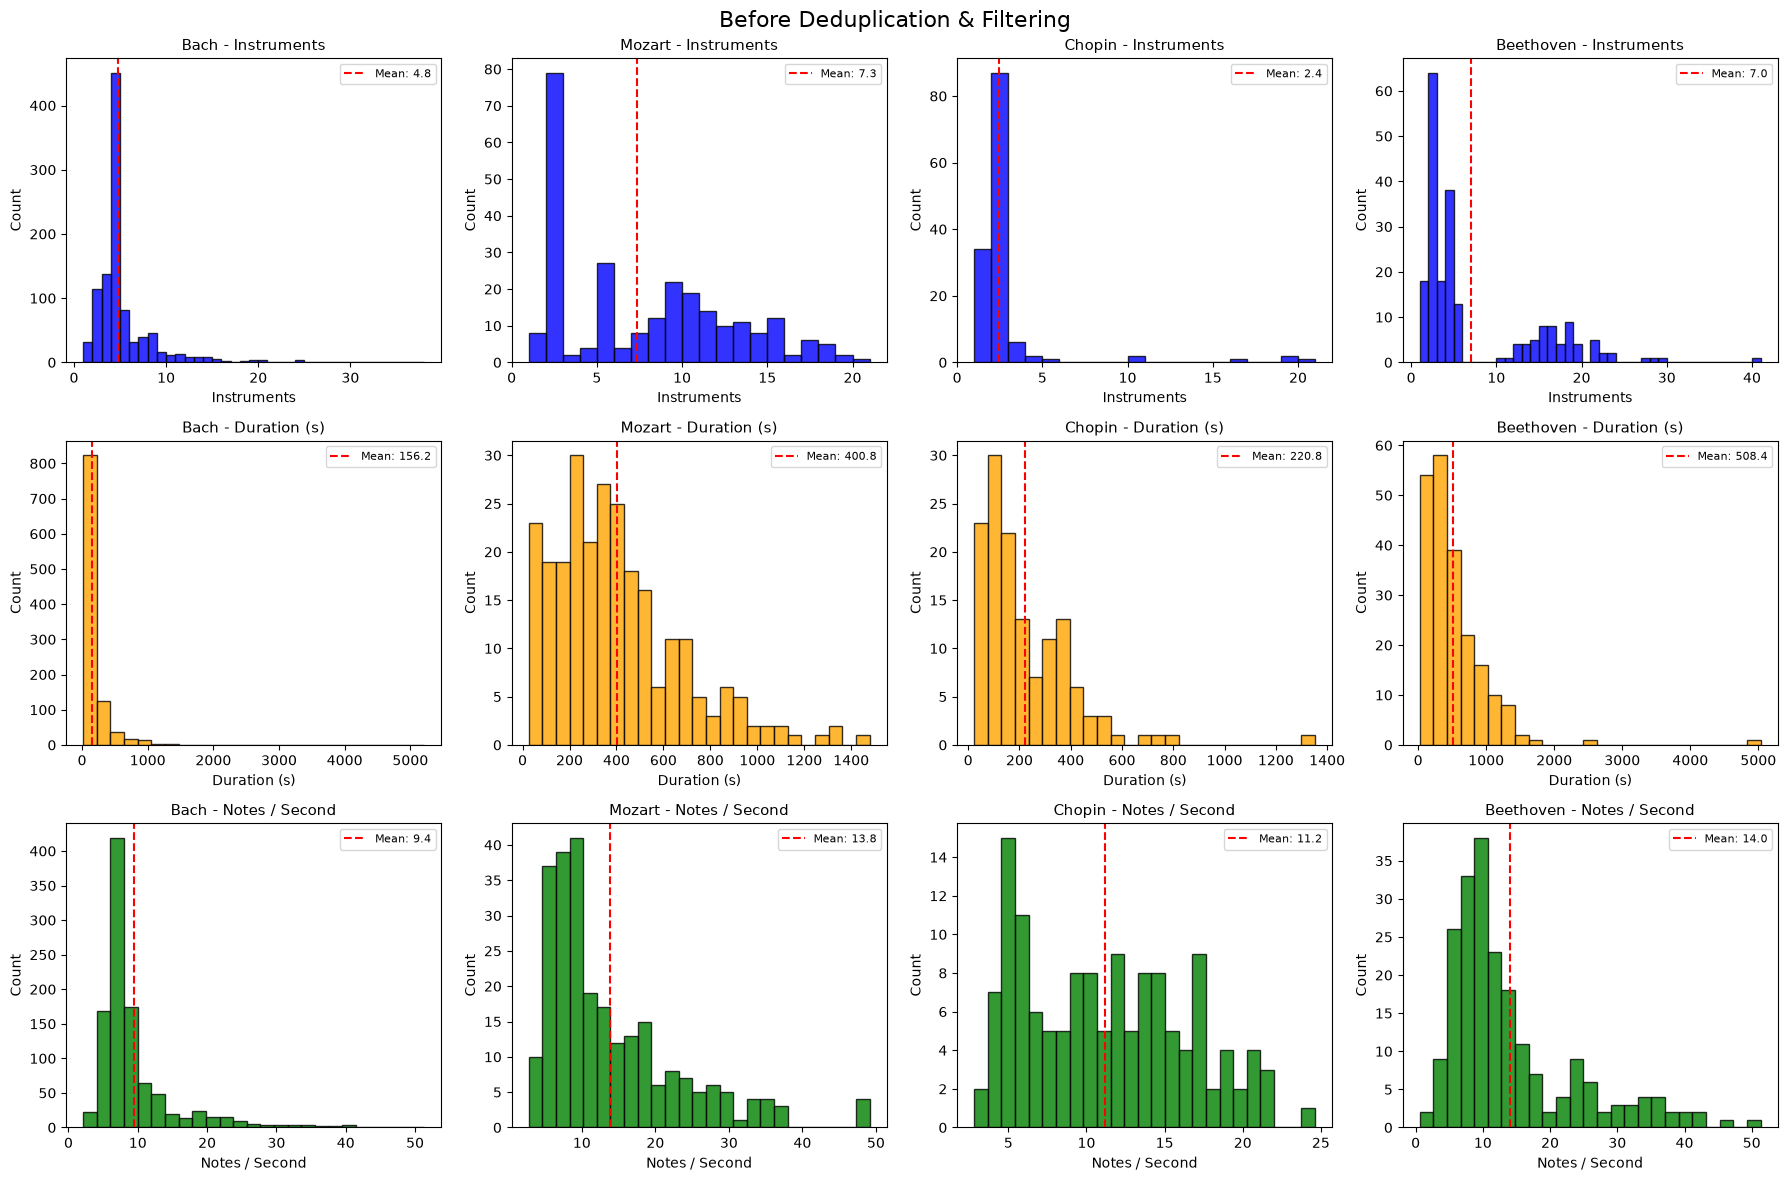

In [6]:
plot_piece_histograms(midi_data, "Before Deduplication & Filtering")

## Remove duplicates
duplicates are removed based on hash calculated earlier

In [10]:
#Duplicate Removal
print("Numbers Before/After Deduplication")
for composer in composers:
    seen_hashes = set()
    kept = {}
    for song_name, info in midi_data[composer].items():
        if info["content_hash"] not in seen_hashes:
            seen_hashes.add(info["content_hash"])
            kept[song_name] = info
    print("  ", composer, len(midi_data[composer]), "->", len(kept))
    midi_data[composer] = kept

Numbers Before/After Deduplication
   Bach 1011 -> 1011
   Mozart 254 -> 254
   Chopin 132 -> 132
   Beethoven 204 -> 204


## Keep only pieces of a reasonable length and remove outliers
Based off of distributions outliers exist in:    
Number of instruments: Capped at 20 instruments - Beethoven has numerous works with greater than 20 instruments    
Duration: Capped at 1000 seconds - Multiple outliers, does not remove much data.    

Remove songs less than 60 seconds to accomodate sliding window





In [11]:
MIN_DURATION, MAX_DURATION = 60, 1000
MIN_INSTRUMENTS, MAX_INSTRUMENTS = 1, 20

print("Numbers Before/After Filtering")
midi_clean = {}
for composer in composers:
    kept = {}
    for song_name, info in midi_data[composer].items():
        good_length = MIN_DURATION <= info["duration"] <= MAX_DURATION
        good_size = MIN_INSTRUMENTS <= info["num_instruments"] <= MAX_INSTRUMENTS
        if good_length and good_size:
            kept[song_name] = info
    midi_clean[composer] = kept
    print("  ", composer, len(midi_data[composer]), "->", len(kept))

Numbers Before/After Filtering
   Bach 1011 -> 582
   Mozart 254 -> 232
   Chopin 132 -> 115
   Beethoven 204 -> 156


## Look at the data again now that it is cleaned up
Data looks more evenly distributed accross composers which results in a more fair comparison

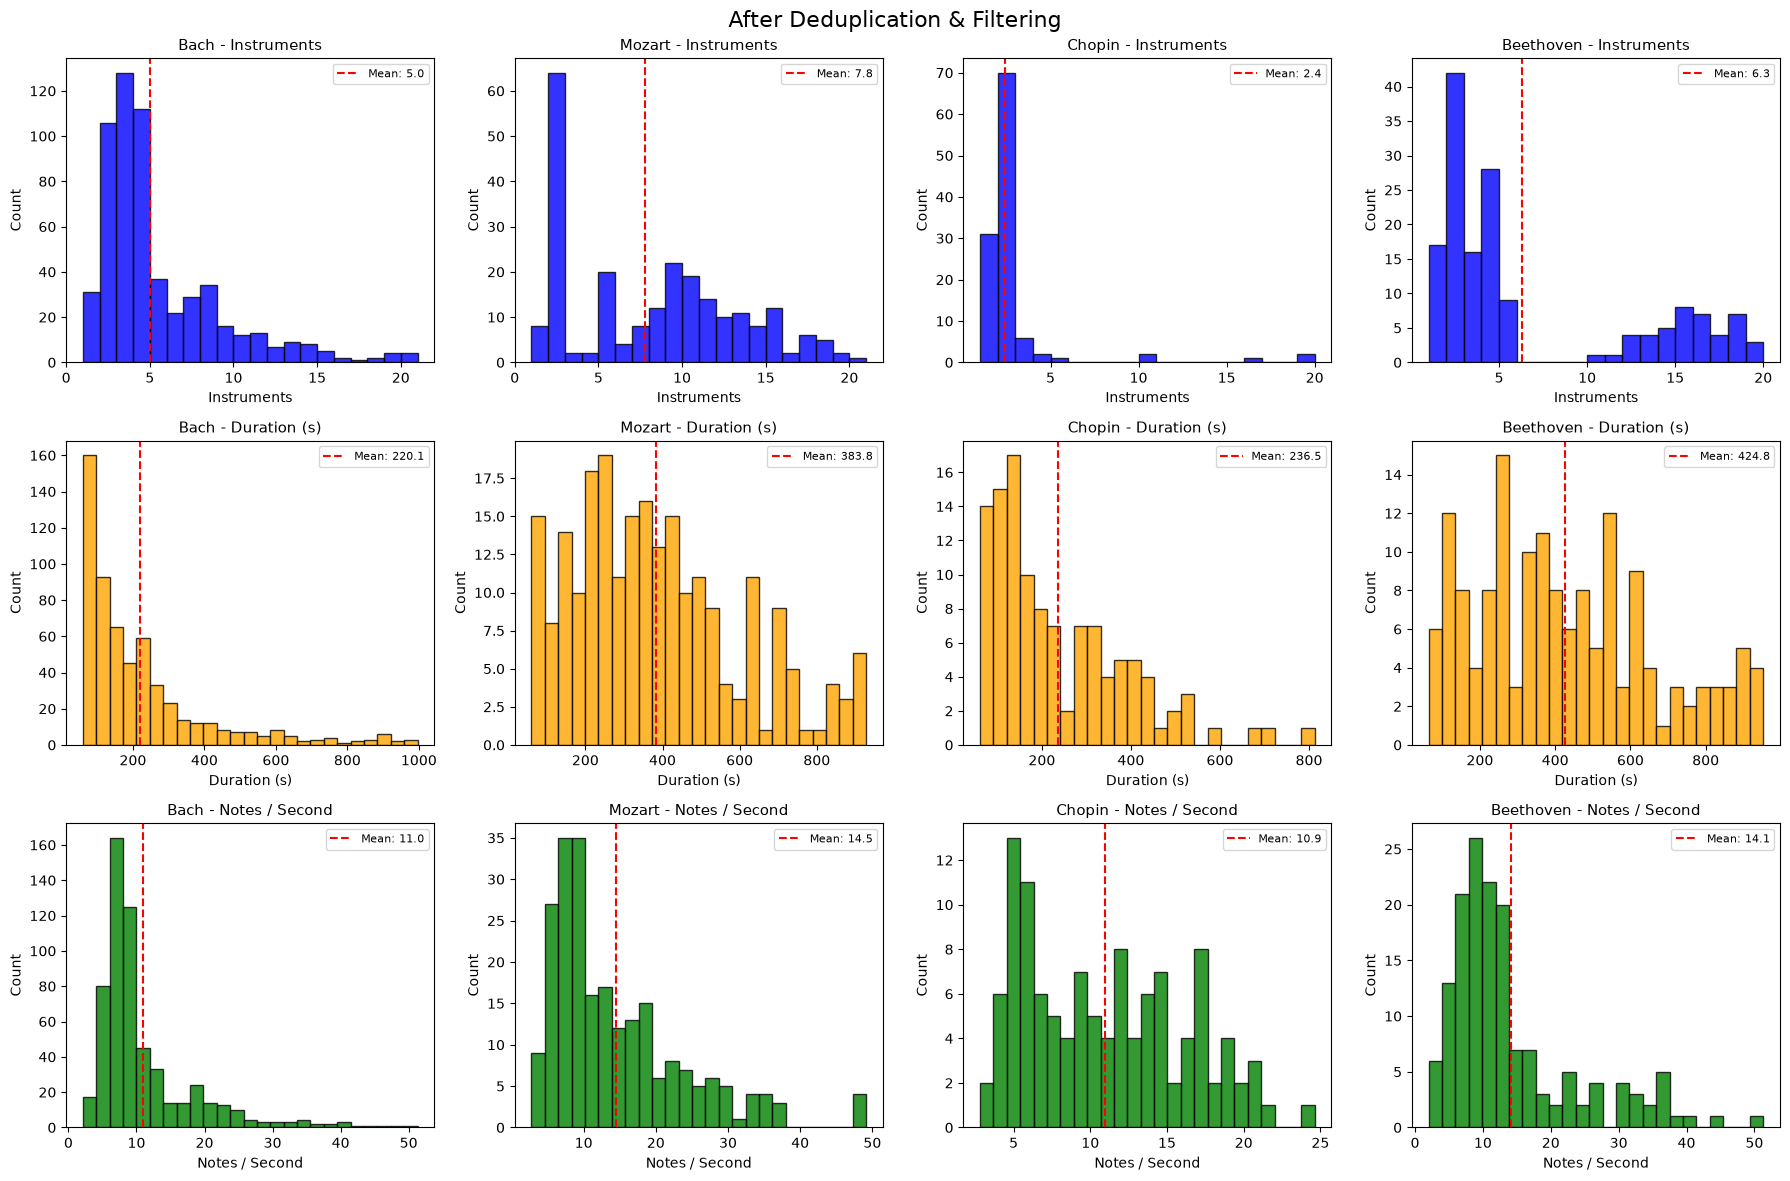

In [12]:
plot_piece_histograms(midi_clean, "After Deduplication & Filtering")

## Feature engineering
Converts each piece’s notes into a DataFrame that includes additional calculated features such as rolling pitch statistics, pitch class, interval, inter-onset interval and simultaneous note count.

In [16]:
#Feature Calculation
for composer in composers:
    for song_name, info in midi_clean[composer].items():
        notes_df = pd.DataFrame(info["notes"]).sort_values("start").reset_index(drop=True)
        notes_df = notes_df.set_index(pd.to_timedelta(notes_df["start"], unit="s"), drop=False)
        rolling_2s = notes_df["pitch"].rolling("2s", closed="both")
        rolling_5s = notes_df["pitch"].rolling("5s", closed="both")
        notes_df["pitch_dev_2s"] = notes_df["pitch"] - rolling_2s.mean()
        notes_df["pitch_dev_5s"] = notes_df["pitch"] - rolling_5s.mean()
        notes_df["pitch_range_2s"] = rolling_2s.max() - rolling_2s.min()
        notes_df["duration"] = notes_df["end"] - notes_df["start"]
        notes_df = notes_df.reset_index(drop=True)
        notes_df["pitch_class"] = notes_df["pitch"] % 12
        notes_df["interval"] = notes_df["pitch"].diff().fillna(0)
        notes_df["ioi"] = notes_df["start"].diff().fillna(0)
        start_times = notes_df["start"].values
        sorted_starts = np.sort(start_times)
        sorted_ends = np.sort(notes_df["end"].values)
        already_started = np.searchsorted(sorted_starts, start_times, side="right")
        already_finished = np.searchsorted(sorted_ends, start_times, side="right")
        notes_df["active_notes"] = already_started - already_finished
        info["notes"] = notes_df.fillna(0)

## Song Snippet Window 
Slides a 30-second window with a 20 second stride across every piece and keeps only windows that contain at least 10 notes. Stores each snippet with its composer and song name.    
songs names are stored to make sure individual songs are not split accross Test/Train/Val datasets. (i.e. Test/Train/Val should only contain songs unique to the dataset)
Snippets should contain atleast 1 note per second - anything less is mostly blank or potentially missing data

In [23]:
#Features
features = ["pitch", "pitch_class", "interval", "pitch_dev_2s", "pitch_dev_5s",
            "pitch_range_2s", "duration", "ioi", "active_notes"]

#Window Definition
SNIPPET_DURATION = 30.0 #Seconds
STRIDE = 20.0 #Seconds
MIN_NOTES_PER_SNIPPET = 30 #1 Note per second

#Apply sliding window
samples = []
for composer in composers:
    for song_name, info in midi_clean[composer].items():
        notes_df = info["notes"]
        for snippet_number, window_start in enumerate(np.arange(0, info["duration"], STRIDE)):
            after_start = notes_df["start"] >= window_start
            before_end = notes_df["start"] < window_start + SNIPPET_DURATION
            snippet = notes_df[after_start & before_end]
            if len(snippet) < MIN_NOTES_PER_SNIPPET:
                continue
            samples.append({"composer": composer,
                            "song_name": song_name,
                            "snippet_index": snippet_number,
                            "n_notes": len(snippet),
                            "n_unique_instruments": snippet["instrument"].nunique(),
                            "original_duration": info["duration"],
                            "notes": snippet[features].reset_index(drop=True)})

print("Total snippets:", len(samples))

Total snippets: 15649


## Split into (train/validation/test) by SONG, not by snippet
Collects unique songs, does a stratified 70/15/15 split by composer, and assigns every snippet to the split of its parent song.

In [24]:
all_songs = sorted(set(s["composer"] + "/" + s["song_name"] for s in samples))

# Stratify by composer so every split gets a similar mix.
song_composers = []
for song_id in all_songs:
    song_composers.append(song_id.split("/")[0])

train_val_songs, test_songs = train_test_split(all_songs, test_size=0.15,
                                               random_state=SEED, stratify=song_composers)

train_val_composers = []
for song_id in train_val_songs:
    train_val_composers.append(song_id.split("/")[0])

# 0.1765 of the remaining 85% works out to roughly 15% of everything.
train_songs, val_songs = train_test_split(train_val_songs, test_size=0.1765,
                                          random_state=SEED, stratify=train_val_composers)

# Remember which split each song belongs to, then send its snippets there.
song_split = {}
for song_id in train_songs:
    song_split[song_id] = "train"
for song_id in val_songs:
    song_split[song_id] = "val"
for song_id in test_songs:
    song_split[song_id] = "test"

splits = {"train": [], "val": [], "test": []}
for sample in samples:
    splits[song_split[sample["composer"] + "/" + sample["song_name"]]].append(sample)

print("Songs --> train:", len(train_songs), "val:", len(val_songs), "test:", len(test_songs))

Songs --> train: 759 val: 163 test: 163


## Balance the composers inside each split
Downsamples each split so every composer has the same number of snippets (the size of the smallest class).

In [26]:
for split_name in ["train", "val", "test"]:
    by_composer = {}
    for composer in composers:
        by_composer[composer] = []
    for sample in splits[split_name]:
        by_composer[sample["composer"]].append(sample)
    # The composer with the fewest snippets sets the limit.
    smallest = min(len(by_composer[c]) for c in composers)
    balanced = []
    for composer in composers:
        balanced.extend(random.sample(by_composer[composer], smallest))
    random.shuffle(balanced)
    splits[split_name] = balanced
    print(split_name, "->", len(balanced), "snippets,", smallest, "per composer")

train -> 4088 snippets, 1022 per composer
val -> 612 snippets, 153 per composer
test -> 732 snippets, 183 per composer


## Histograms of the snippets per composer

Plots note-count and unique-instrument distributions. This is the actual data that will be fed into the model

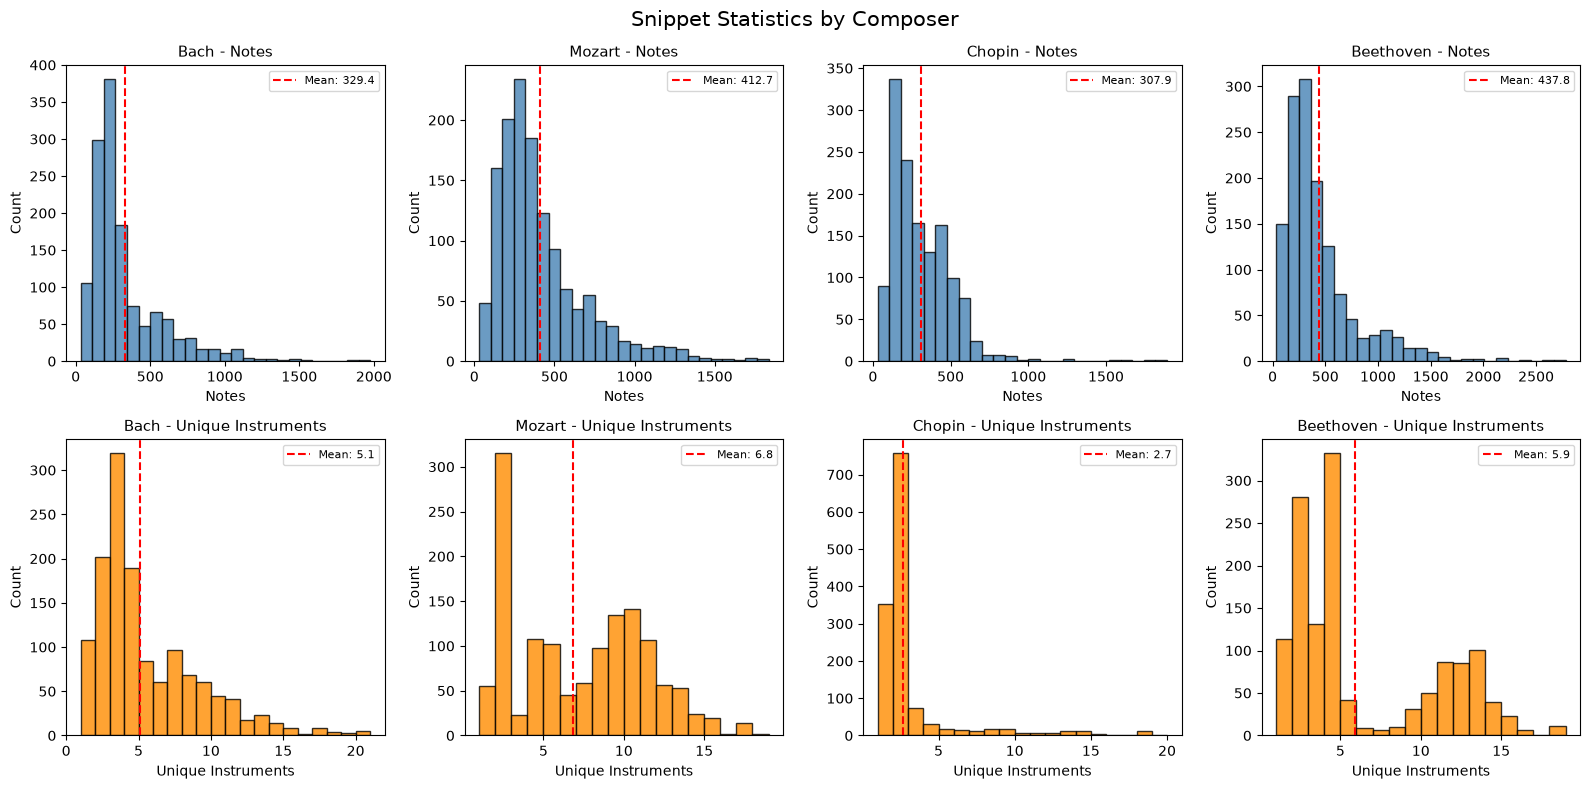

In [27]:
all_snippets = splits["train"] + splits["val"] + splits["test"]
metrics = ["n_notes", "n_unique_instruments"]
labels = ["Notes", "Unique Instruments"]
colors = ["steelblue", "darkorange"]

figure, axes = plt.subplots(2, 4, figsize=(16, 8))
figure.suptitle("Snippet Statistics by Composer", fontsize=15)
for column, composer in enumerate(composers):
    for row in range(2):
        values = []
        for snippet in all_snippets:
            if snippet["composer"] == composer:
                values.append(snippet[metrics[row]])
        draw_histogram(axes[row, column], values, labels[row], colors[row],
                       composer + " - " + labels[row], whole_numbers=(row == 1))
plt.tight_layout()
plt.show()

## Decide how many notes to feed the model    
Sets MAX_LENGTH to the nearest common size near the 75th percentile of training snippet lengths. Creates the composer-to-label dictionary.     
This step is done to ensure certain composers are not unfairly zero-padded or truncated more than others - Calculated off training data only

In [28]:
p75 = np.percentile([s["n_notes"] for s in splits["train"]], 75)
MAX_LENGTH = min([128, 256, 384, 512, 768, 1024], key=lambda x: abs(x - p75))
print(f"MAX_LENGTH = {MAX_LENGTH}")

composer_to_label = {"Bach": 0, "Mozart": 1, "Chopin": 2, "Beethoven": 3}

MAX_LENGTH = 512


## Build the X and y arrays    
Pads or truncates every snippet to exactly MAX_LENGTH notes and converts the three splits into NumPy arrays X and y.

In [30]:
#Functionm to pad/truncate based on MAX_LENGTH calculated earlier
def pad_or_truncate(notes_df, max_length=MAX_LENGTH):
    """Make every snippet exactly max_length rows long."""
    data = notes_df.values.astype(np.float32)
    if len(data) > max_length:
        return data[:max_length]
    padded = np.zeros((max_length, data.shape[1]), dtype=np.float32)
    padded[:len(data)] = data
    return padded

#Build X y
def build_arrays(split_name):
    """Turn a list of snippets into the X and y arrays Keras wants."""
    X_list, y_list = [], []
    for sample in splits[split_name]:
        X_list.append(pad_or_truncate(sample["notes"]))
        y_list.append(composer_to_label[sample["composer"]])
    return np.array(X_list), np.array(y_list)

X_train, y_train = build_arrays("train")
X_val, y_val = build_arrays("val")
X_test, y_test = build_arrays("test")


## Scale the features
Fits a StandardScaler on the real (non-padded) training notes only. Applies scale to all three splits while leaving the zero-padding untouched. One-hot encodes the labels.

In [35]:
# Flatten all training sequences so we can fit the scaler on every real note at once
n_features = len(features)
all_train_rows = X_train.reshape(-1, n_features)

# Identify rows that are actual notes (not the zero-padding)
is_real_note = ~np.all(all_train_rows == 0, axis=1)

# Fit the scaler only on real notes from the training set (not the zero-padding)
scaler = StandardScaler()
scaler.fit(all_train_rows[is_real_note])

def scale_features(X):
    X_scaled = X.copy()
    for i in range(len(X_scaled)):
        real_rows = ~np.all(X_scaled[i] == 0, axis=1)
        X_scaled[i][real_rows] = scaler.transform(X_scaled[i][real_rows])
    return X_scaled

# Apply the same scaling to all three splits
X_train = scale_features(X_train)
X_val = scale_features(X_val)
X_test = scale_features(X_test)

#One-hot encode
y_train_cat = to_categorical(y_train, 4)
y_val_cat = to_categorical(y_val, 4)
y_test_cat = to_categorical(y_test, 4)

#Finalized Test/Train/Val split 
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (4088, 512, 9)  Val: (612, 512, 9)  Test: (732, 512, 9)


## Functions for Models 
Creates EarlyStopping and ReduceLROnPlateau callbacks and a function that plots train/val loss and accuracy curves.

In [36]:
#EarlyStopping and Reduce LR on Platue
def make_callbacks():
    early_stopping = EarlyStopping(monitor="val_accuracy", patience=6,
                                   restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                  patience=3, min_lr=1e-6, verbose=1)
    return [early_stopping, reduce_lr]

#Function to plot loss and accuracy per epoch 
def plot_training(history, model_name):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i, metric in enumerate(["loss", "accuracy"]):
        axes[i].plot(history.history[metric], label="train")
        axes[i].plot(history.history["val_" + metric], label="val")
        axes[i].set_title(model_name + " - " + metric)
        axes[i].set_xlabel("Epoch")
        axes[i].legend()
    plt.tight_layout()
    plt.show()

## Model 1: bidirectional LSTM with attention
bidirectional LSTM     
two layers     
self-attention      
global average pooling     
4-class softmax      
Adam      
categorical cross-entropy.

In [37]:
#Apply Seed for consistent results
tf.keras.utils.set_random_seed(SEED)

#Model1 LSTM
inputs = Input(shape=(MAX_LENGTH, n_features))
x = Masking(mask_value=0.0)(inputs)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.5)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.5)(x)
x = Attention()([x, x])
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(4, activation="softmax")(x)

lstm = Model(inputs, outputs)
lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="categorical_crossentropy", metrics=["accuracy"])
lstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 512, 9)    │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 512, 9)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 512)       │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 512, 128)  │     37,888 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512, 128)  │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 512, 128)  │     98,816 │ dropout_3[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512, 128)  │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 512, 128)  │          0 │ dropout_4[0][0],  │
│ (Attention)         │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor_1 │ (None, 512)       │          0 │ any_1[0][0]       │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_1[0][0… │
│ (GlobalAveragePool… │                   │            │ convert_to_tenso… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        132 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140,964 (550.64 KB)

 Trainable params: 140,964 (550.64 KB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM
Fits the LSTM for up to 40 epochs with batch size = 64

In [38]:
lstm_history = lstm.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                        epochs=40, batch_size=64, callbacks=make_callbacks(), verbose=1)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.4391 - loss: 1.2351 - val_accuracy: 0.4281 - val_loss: 1.2038 - learning_rate: 0.0010
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5098 - loss: 1.1221 - val_accuracy: 0.5000 - val_loss: 1.1355 - learning_rate: 0.0010
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5624 - loss: 1.0458 - val_accuracy: 0.5000 - val_loss: 1.1156 - learning_rate: 0.0010
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5969 - loss: 0.9806 - val_accuracy: 0.5229 - val_loss: 1.0437 - learning_rate: 0.0010
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.6492 - loss: 0.8897 - val_accuracy: 0.5719 - val_loss: 0.9807 - learning_rate: 0.0010
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6776 - loss: 0.8335 - val_accuracy: 0.5752 - val_loss: 0.9773 - learning_rate: 0.0010
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7055 - loss: 0.7765 - val_accuracy: 

## Evaluate the LSTM

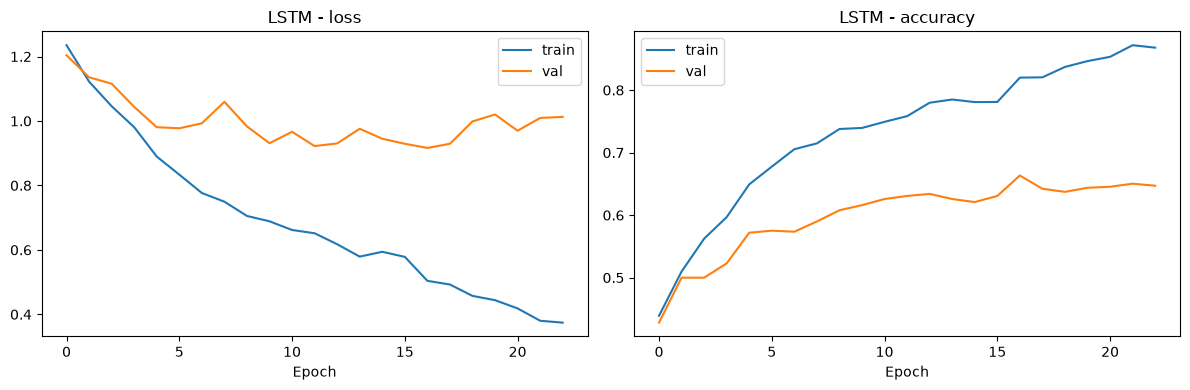

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step
LSTM test accuracy: 0.6899
              precision    recall  f1-score   support

        Bach     0.6872    0.8525    0.7610       183
      Mozart     0.6548    0.6011    0.6268       183
      Chopin     0.8263    0.7541    0.7886       183
   Beethoven     0.5941    0.5519    0.5722       183

    accuracy                         0.6899       732
   macro avg     0.6906    0.6899    0.6871       732
weighted avg     0.6906    0.6899    0.6871       732



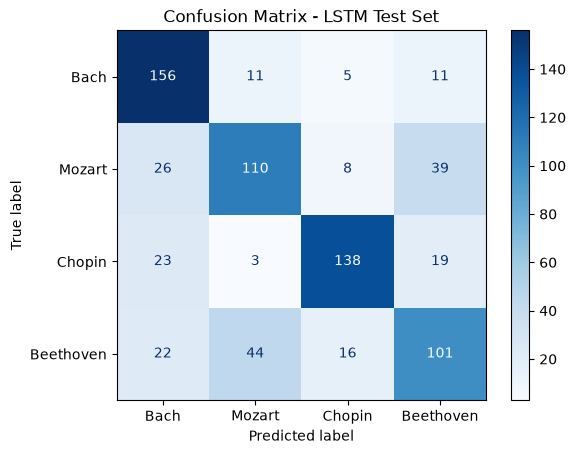

In [39]:
#Training Curve
plot_training(lstm_history, "LSTM")
y_pred_lstm = np.argmax(lstm.predict(X_test), axis=1)
lstm_accuracy = lstm.evaluate(X_test, y_test_cat, verbose=0)[1]

#Test Accuracy + classification report
print("LSTM test accuracy:", round(lstm_accuracy, 4))
print(classification_report(y_test, y_pred_lstm, target_names=composers, digits=4))

#Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lstm),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - LSTM Test Set")
plt.show()

## Model 2: 1D CNN    
three-block 1-D CNN    
global max pooling    
4-class softmax    
Adam      
categorical cross-entropy.    

In [87]:
#Apply Seed for consistent results
tf.keras.utils.set_random_seed(SEED)

#Model2 CNN
inputs = Input(shape=(MAX_LENGTH, n_features))
x = Conv1D(64, 5, padding="same", activation="relu")(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Conv1D(128, 5, padding="same", activation="relu")(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.25)(x)
x = Conv1D(144, 5, padding="same", activation="relu")(x)
x = GlobalMaxPooling1D()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(4, activation="softmax")(x)

cnn = Model(inputs, outputs)
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

print("LSTM parameters:", lstm.count_params())
print("CNN parameters: ", cnn.count_params())

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 512, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 512, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 128, 144)       │        92,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_11         │ (None, 144)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,108 (551.20 KB)

 Trainable params: 141,108 (551.20 KB)

 Non-trainable params: 0 (0.00 B)

LSTM parameters: 140964
CNN parameters:  141108


## Train the CNN    
Fits the LSTM for up to 40 epochs with batch size = 64

In [88]:
cnn_history = cnn.fit(X_train, y_train_cat, validation_data=(X_val, y_val_cat),
                      epochs=40, batch_size=64, callbacks=make_callbacks(), verbose=1)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3351 - loss: 1.3688 - val_accuracy: 0.3807 - val_loss: 1.3355 - learning_rate: 0.0010
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3831 - loss: 1.2684 - val_accuracy: 0.3954 - val_loss: 1.2670 - learning_rate: 0.0010
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4415 - loss: 1.2107 - val_accuracy: 0.4641 - val_loss: 1.1994 - learning_rate: 0.0010
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4890 - loss: 1.1549 - val_accuracy: 0.4477 - val_loss: 1.1696 - learning_rate: 0.0010
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5000 - loss: 1.1249 - val_accuracy: 0.5229 - val_loss: 1.1195 - learning_rate: 0.0010
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5423 - loss: 1.0874 - val_accuracy: 0.5180 - val_loss: 1.1331 - learning_rate: 0.0010
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5548 - loss: 1.0456 - val_acc

## Evaluate the CNN

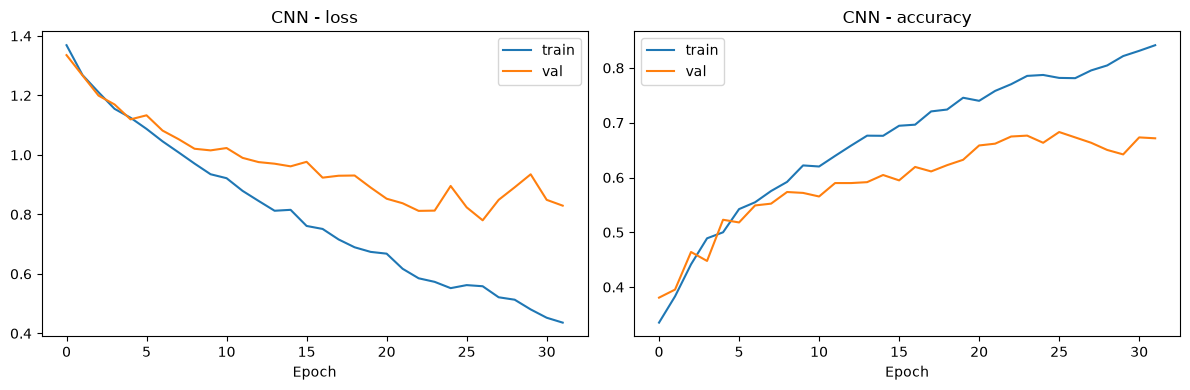

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
CNN test accuracy: 0.6776
              precision    recall  f1-score   support

        Bach     0.7513    0.7923    0.7713       183
      Mozart     0.5242    0.7705    0.6239       183
      Chopin     0.8598    0.7705    0.8127       183
   Beethoven     0.6509    0.3770    0.4775       183

    accuracy                         0.6776       732
   macro avg     0.6965    0.6776    0.6713       732
weighted avg     0.6965    0.6776    0.6713       732



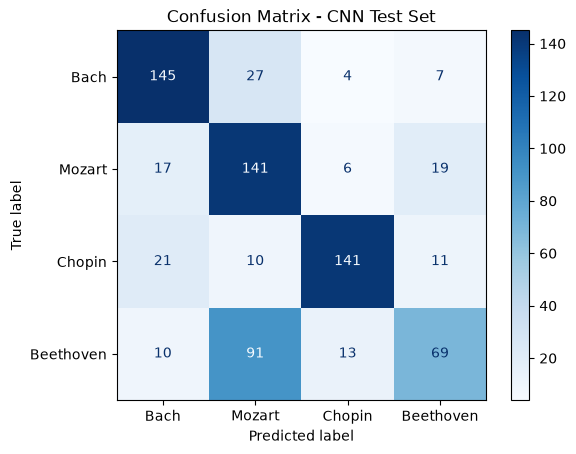

In [89]:
#Training Curve
plot_training(cnn_history, "CNN")
y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)
cnn_accuracy = cnn.evaluate(X_test, y_test_cat, verbose=0)[1]

#Test Accuracy + classification report
print("CNN test accuracy:", round(cnn_accuracy, 4))
print(classification_report(y_test, y_pred_cnn, target_names=composers, digits=4))

#Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
                       display_labels=composers).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - CNN Test Set")
plt.show()

## Compare the two models

Compares Models

In [90]:
print("LSTM:", lstm.count_params(), "parameters, test accuracy", round(lstm_accuracy, 4))
print("CNN: ", cnn.count_params(), "parameters, test accuracy", round(cnn_accuracy, 4))
print("Random guessing would be about 0.25")

LSTM: 140964 parameters, test accuracy 0.6899
CNN:  141108 parameters, test accuracy 0.6776
Random guessing would be about 0.25
